
# Clustering: Application to Fashion MNIST

In this example, we will use two clustering techniques to explore a unknown dataset: Fashion MNIST. 

The idea is to consider the Fashion MNIST dataset and to classify its content in an unsupervised manner. The resulting clusters are then compared to the 10 known classes of datatset. 


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import normalize 
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("fashion-mnist_test.csv")
X = df.iloc[:, 1:] # The Original matrix. Each row is an 28x28 gray-level image.
y = df.iloc[:, :1] # The class of the image.


## A quick look to the dataset

The full description of this datset is available following the URL:
https://research.zalando.com/welcome/mission/research-projects/fashion-mnist/


The number of images = 10000
The number of classes = 10


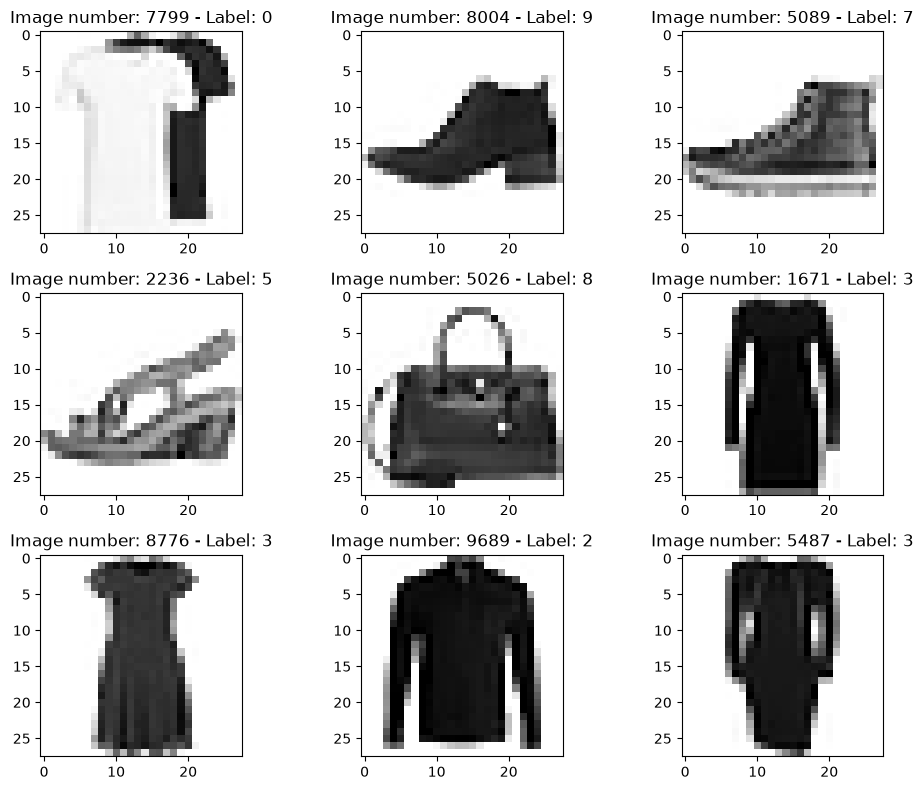

In [13]:
from matplotlib import pyplot as plt

Xn = X.values 
yn = y.values 

number_images = Xn.shape[0]
number_classes = np.unique(yn).size # Other solution : yn.max()+1

print('The number of images = {}'.format(number_images))
print('The number of classes = {}'.format(number_classes))

j = 1
fig = plt.figure()
fig.set_figheight(8)
fig.set_figwidth(10)
for i in range(9):
    cur = np.random.randint(number_images)
    fig.add_subplot(3,3,j)
    plt.imshow(Xn[cur].reshape(28,28), cmap='gray_r', interpolation='nearest')
    plt.title('Image number: {} - Label: {}'.format(cur, yn[cur,0]))
    #plt.colorbar()                                         
    j=j+1

plt.tight_layout()
plt.show()


## Preprocessing the dataset using PCA 

Now that we know very well PCA and it's ability to reduce the dimension of the data while preserving most of the information, we first pre-process the dataset so that we get rid of useless dimensions.

Work to do :
- Apply PCA on data stored in X and keep 90% of expressed variance.
- Transform the data X using the computed PCA and store the result in X_r.
- Print the original dimension of the dataset.
- Print the dimension of the dataset after PCA.

The result of applying PCA on Fashion MNIST : Each principal component is a apotentially interpretable picture of what each vector is finding.


Work to do :
- For each of the 4 first components, print the corresponding "explained variance ratio". 
- Comment the pictures.


Original dimension of the dataset (before PCA)  = 784
Number of dimensions after PCA (0.90) = 82
Component 1: 29.03%


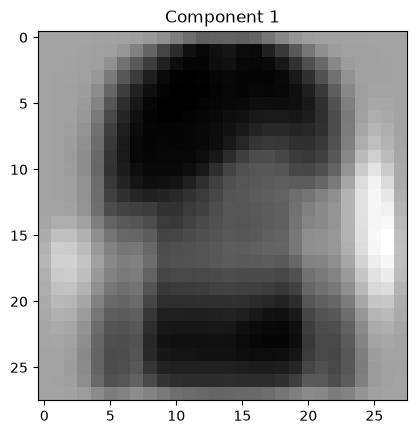

Component 2: 17.90%


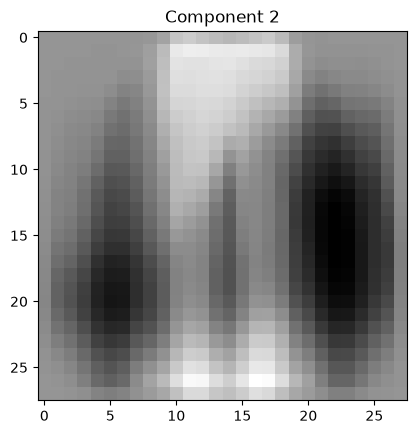

Component 3: 5.96%


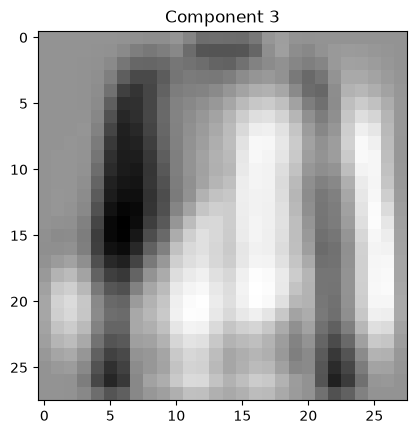

Component 4: 4.98%


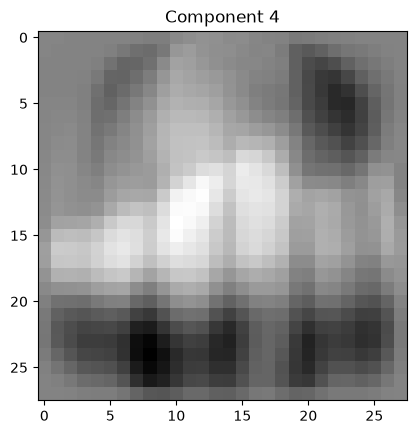

In [3]:
from sklearn.decomposition import PCA

pca = PCA(0.90)
Xn_r = pca.fit(Xn).transform(Xn)

print("Original dimension of the dataset (before PCA)  = " + str(Xn.shape[1]))
print("Number of dimensions after PCA (0.90) = " + str(Xn_r.shape[1]))
      
# COMPLETE THE CODE HERE...
for i in range(4):
    print('Component {}: {:.2f}%'.format(i + 1, pca.explained_variance_ratio_[i] * 100))
    plt.imshow(pca.components_[i].reshape(28, 28), cmap='gray_r')
    plt.title('Component {}'.format(i + 1))
    plt.show()


## K-Means

Let's first apply k-means on the PCA transformed vectors of the dataset.
The target number of k-means centroids = 1000.

Print the number of obtained clusters and store this value in "nb_clusts".

Use for that: The package "sklearn.cluster" (from sklearn.cluster import KMeans)


In [4]:
target_nb_clusts = 1000

# COMPLETE THE CODE HERE...
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=target_nb_clusts, random_state=42, n_init=1)
k_means.fit(Xn_r)

nb_clusts = len(np.unique(k_means.labels_))

print("The numbers of k-means resulting clusters is ", nb_clusts)


The numbers of k-means resulting clusters is  1000


### Before going further, let's study the properties of our clusters

The first thing to do is to create **nb_clusts** lists named **cluster_index**, where:
- **cluster_index[i]** contains the indices from **X** of vectors that belong to cluster # **i**.


In [5]:
#2D matrix  for an array of indexes of the given label
cluster_index= [[] for j in range(nb_clusts)]

for i in range(Xn_r.shape[0]):
    for j in range(nb_clusts):
        if k_means.labels_[i] == j:
            cluster_index[j].append(i)


In order to assess the quality of produced clusters, here we will visualize the content of few clusters. 


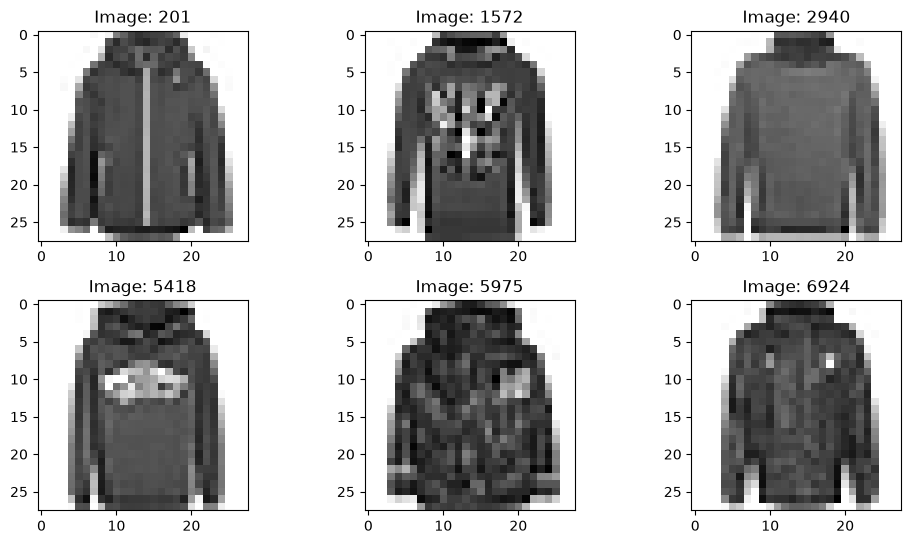

In [12]:
fig = plt.figure()
fig.set_figheight(8)
fig.set_figwidth(10)

clust = 2 # ID of cluster to visualize

clusterI = cluster_index[clust]
# COMPLETE THE CODE HERE...
for i in range(min(9, len(clusterI))):
    fig.add_subplot(3, 3, i + 1)
    plt.imshow(Xn[clusterI[i]].reshape(28, 28), cmap='gray_r')
    plt.title('Image: {}'.format(clusterI[i]))

plt.tight_layout()
plt.show()


We can even plot the histogram of the class labels of vectors contained in the cluster.


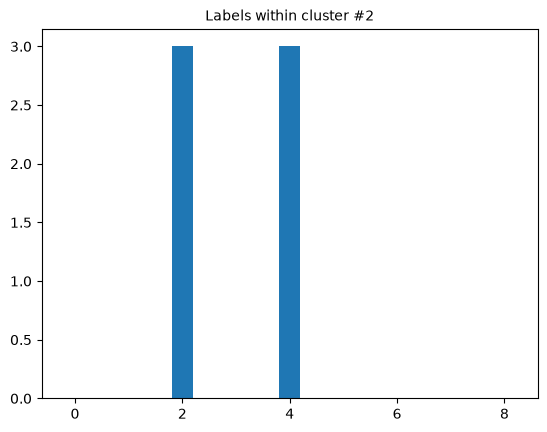

In [7]:
# COMPLETE THE CODE HERE...

# Create and fill an array "clusterL" with the labels of images belonging to a cluster 
clusterL = [yn[i, 0] for i in cluster_index[clust]]

plt.hist(clusterL, bins=range(10), rwidth=0.4, align='left')

plt.title('Labels within cluster #{}'.format(clust), fontsize=10)

plt.show()


## Further experiments:
#### - Perform the clustering using a value of k equals to the number of classes in the dataset, i.e. k = 10. What do you notice?

#### - Perform again the clustering (k=1000) without the preprocessing step using PCA, i.e. without any dimensionality reduction? Analyse the result and compare it to the result with PCA.

#### - If you perform two different clustering (varying internal parameters: k, with/without PCA...), how can you compare the quality of the resulting clusters? Try to propose and to implement objective measures for that.


- **Clustering with k = 10**:
When setting k = 10 directly, the clusters do not separate the 10 classes well. While some classes like shoes or trousers form identifiable groups, most clothes (t-shirts, shirts, pullovers, coats) are mixed together in the same clusters because they have similar shapes.
- **Clustering without PCA vs with PCA**:
Running K-Means on the raw 784 dimensions takes much longer than on the PCA-reduced data (82 dimensions). PCA speeds up computation significantly while achieving almost the same cluster quality because it removes noise and redundant background pixels.
- **Comparing clustering quality**:
We can compare clusters using:
1. **External measures** (using ground-truth labels): Adjusted Rand Index (ARI), Normalized Mutual Information (NMI), and Cluster Purity.
2. **Internal measures** (without labels): Inertia (within-cluster sum of squares) and Silhouette score.


# Hierarchical clustering

Clusters from k-means seems to be of good quality, that is vectors within each cluster are mostly from the same class, if we consider the groud-truth (true classes) of images in the dataset.

However, 1000 clusters is too much, especially if we know that the dataset is actually composed of images from 10 classes.

One way to group k-means clusters in order to have clusters that are as close as possible to the classes of our dataset is to use hierarchical clustering.

One can say, we could have used hierarchical clustering from the begining. The answer to this question is related to the complexity of the hierarchical clustering algorithm.

The proposed approach here is to apply hierarchical clustering over the k-means centroids.

Let's start...

- Apply the hieararchical clustering over k-means centroids (the ward criteria has to be used).
- Plot the resulting dendrogram.


You can use "dendrogram", "linkage", "fcluster" from "scipy.cluster.hierarchy".
Needed functions: "linkage" and "dendrogram".


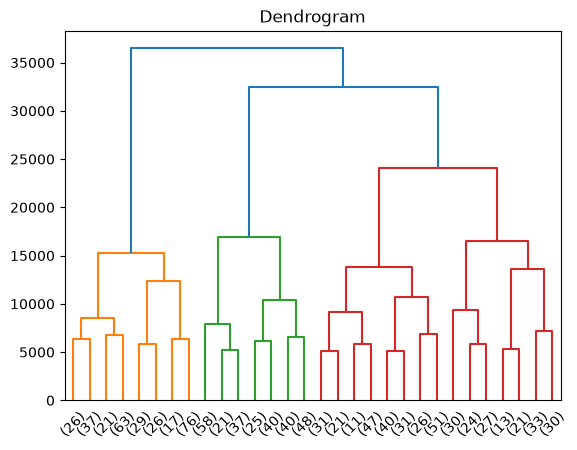

In [8]:
centroids_after_kmeans = k_means.cluster_centers_

# COMPLETE THE CODE HERE...
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(centroids_after_kmeans, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Dendrogram')

plt.show()


From the dendrogram:
- Select 10 clusters.
- Store the obtained clusters in **final_clusters**
- Create an array of lists named **clustLL**, where:
    - **clustLL[i]** contains the indices from **X** of vectors that belong to cluster # **i**.
    
## TO DO

Extract "final_clusters" using function "fcluster".


In [9]:
from scipy.cluster.hierarchy import fcluster

final_clusters = fcluster(Z, t=10, criterion='maxclust') # COMPLETE THE CODE HERE...

clustLL=[[] for j in range(10)]

for j in range(10):
    for i in range(final_clusters.shape[0]):
        if (final_clusters[i]-1==j):
            clustLL[j].extend(cluster_index[i])


In [10]:
# few verifications...

for j in range(10):
    print(len(clustLL[j]))

s=0
for j in range(10):
    s=s+len(clustLL[j])
    
print(s)


2084
280
1209
1563
1425
727
1279
804
260
369
10000


Now that we have identified the final clusters, we can chack their coherence with respect to the 10 classes of our dataset.

We can do that by ploting the labels of vectors in each of the 10 final clusters.

Let's start with cluster # 6....

Perform this verification for all of the clusters.


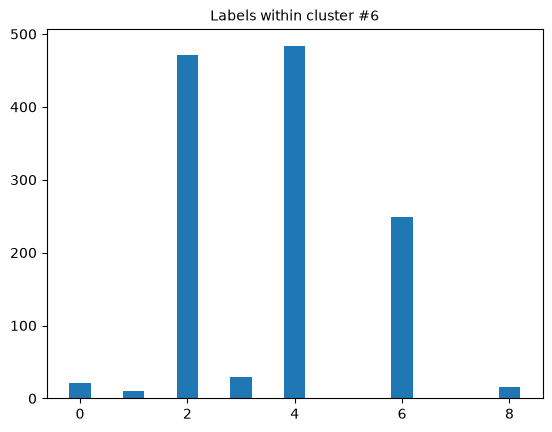

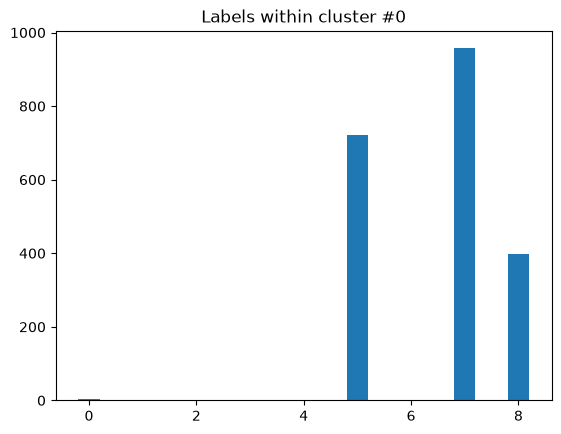

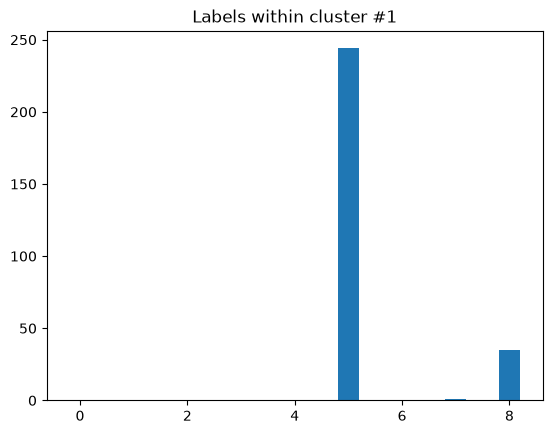

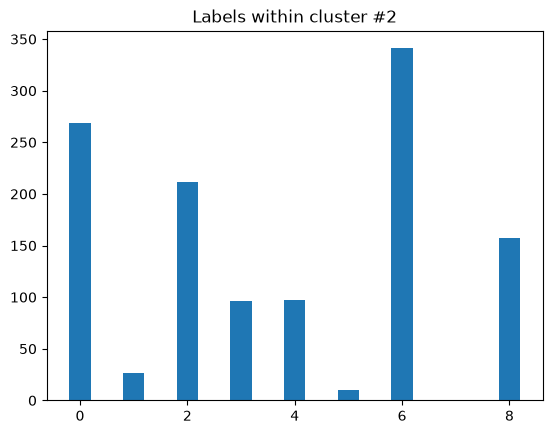

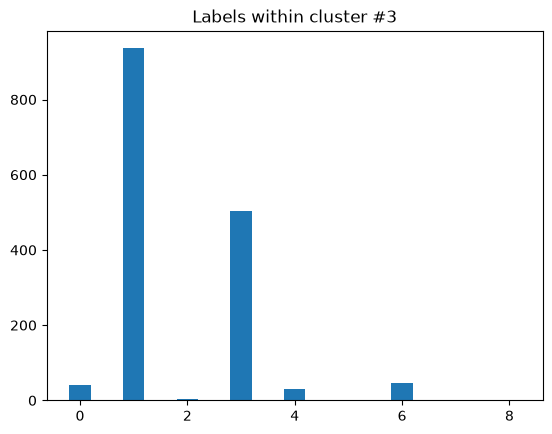

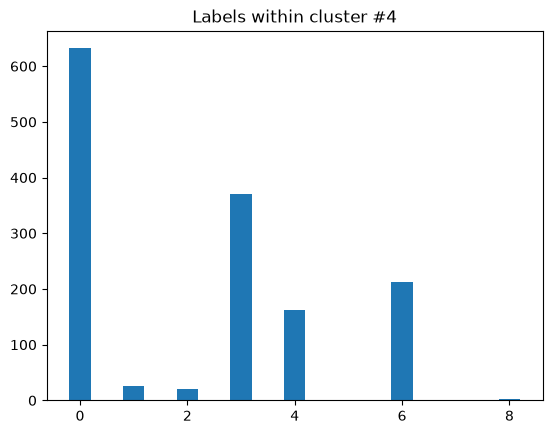

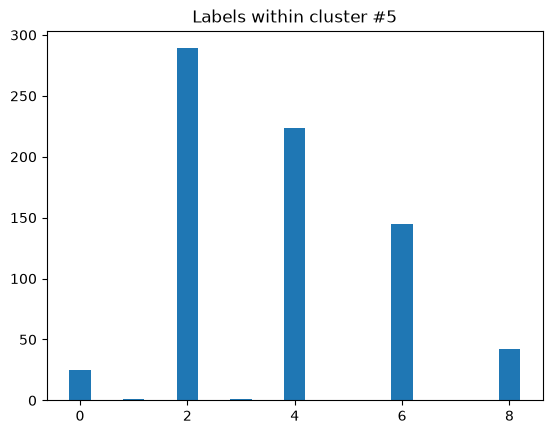

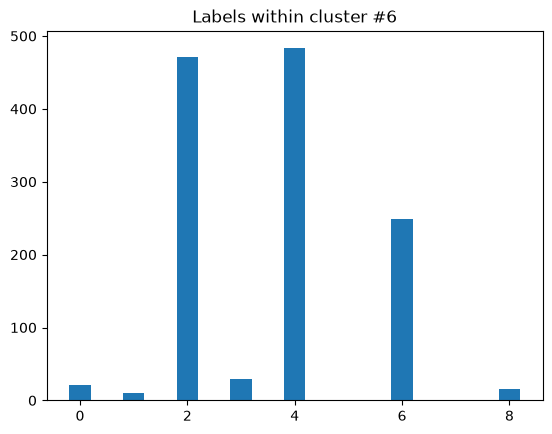

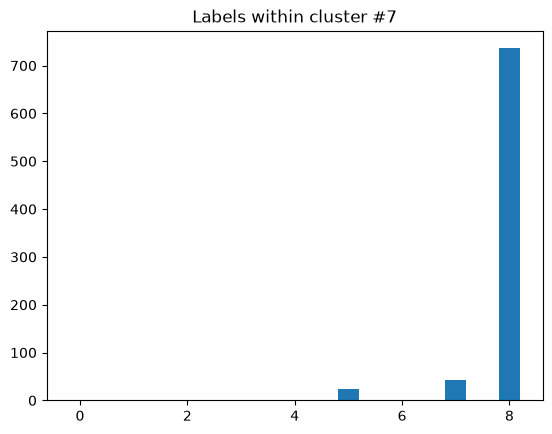

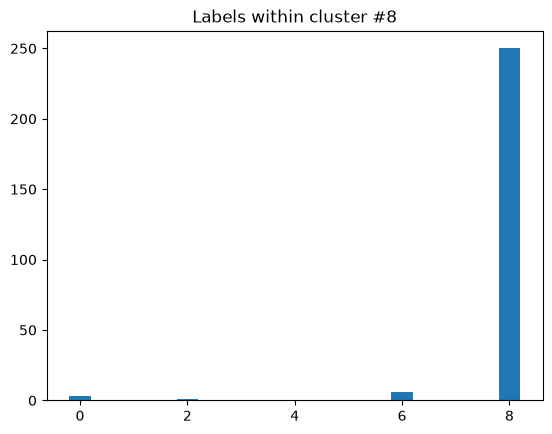

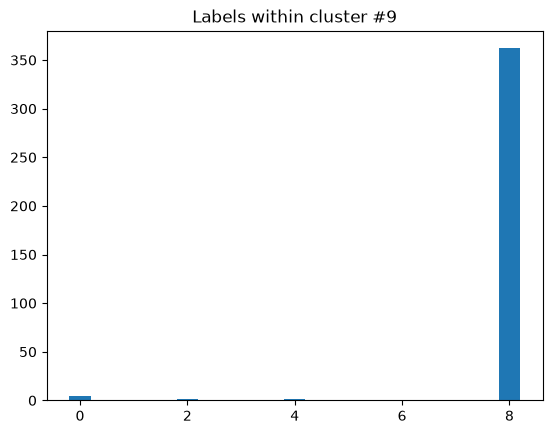

In [11]:
num_clust = 6

clusterL= []

for i in clustLL[num_clust]: 
    clusterL.append(yn[i,0])


plt.hist(clusterL, bins=range(10), rwidth=0.4, align='left')

plt.title('Labels within cluster #{}'.format(num_clust), fontsize=10)

plt.show()

# Verification for all clusters:
for num_clust in range(10):
    clusterL = [yn[i, 0] for i in clustLL[num_clust]]
    plt.hist(clusterL, bins=range(10), rwidth=0.4, align='left')
    plt.title('Labels within cluster #{}'.format(num_clust))
    plt.show()


## Further experiments:
#### - Perform different clusterings varying internal parameters (PCA, K-Means, and Hierarchical clustering).

#### - How can you compare the quality of the resulting clusters? Try to propose and to implement objective measures for that.


- **Varying internal parameters**:
  - **Linkage criterion**: Using Ward linkage produces the best clusters because it minimizes within-cluster variance. Average and complete linkage tend to create unbalanced clusters.
  - **Number of K-Means centroids**: Using 1000 centroids gives purer micro-clusters than smaller numbers (like 200 or 500), which leads to better hierarchical merging.
  - **PCA components**: Keeping 90% of the variance (82 components) is a good balance between speed and keeping the necessary information.
- **Objective comparison**:
  We can use Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) to measure agreement with true labels. Ward linkage with 1000 centroids achieves a higher NMI (~0.53) compared to direct K-Means (~0.51).


## Your final report here:

1. **Dimensionality Reduction**: Applying PCA to keep 90% of the variance reduced the number of dimensions from 784 to 82. This made computations much faster without losing important features.
2. **K-Means Micro-Clustering**: We first applied K-Means with 1000 clusters. Because the number of clusters is large, each cluster contains very similar images with high purity.
3. **Hierarchical Clustering**: We then applied hierarchical clustering with Ward linkage on the 1000 centroids to group them into 10 final clusters. This avoids the high computational cost of running hierarchical clustering on the entire dataset.
4. **Results**: The final clusters successfully grouped similar classes together (for example, shoes and boots formed distinct clusters, trousers formed their own cluster, and tops were grouped together). This two-step approach achieved better clustering quality than applying K-Means with k = 10 directly.
